# W03 — LPBF historical-corpus data-quality audit

This notebook is the runnable companion to `data_integrity_report.json`. It
reviews derived audit outputs only; it does not modify the H0 historical corpus.


## tl;dr

- Validate manifest grain, split isolation, files, hashes, and bounding boxes.
- Show the scale of each split and the observed duplicate-screening signals.
- Keep label semantics and manufacturing-build independence explicitly
  unresolved until human and provenance gates are completed.


## Context & Methods

The audit runs at one manifest row per `sample_id`. Specimen and specimen–view
groups are the available independence units. Every declared image and label hash
was recomputed. Exact dHash equality is used only as a visual-similarity screen;
it is not interpreted as proof of duplicate acquisition. Static corpus
timeliness is not a quality dimension here; provenance and test-access history
are reported instead.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORT_PATH = ROOT / "data" / "manifests" / "data_integrity_report.json"
IMAGE_MANIFEST_PATH = ROOT / "data" / "manifests" / "image_manifest.csv"
GROUP_MANIFEST_PATH = ROOT / "data" / "manifests" / "group_manifest.csv"

report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
images = pd.read_csv(IMAGE_MANIFEST_PATH)
groups = pd.read_csv(GROUP_MANIFEST_PATH)
report["status"], images.shape, groups.shape


('PASS_WITH_LIMITATION', (5632, 43), (352, 13))

## Data


In [2]:
split_order = ["train", "validation", "test"]
split_table = (
    images.groupby("split")
    .agg(images=("sample_id", "size"), specimens=("specimen", "nunique"), groups=("group_id", "nunique"))
    .reindex(split_order)
)
display(split_table)

lineage_table = pd.DataFrame({
    "measure": ["rows", "specimens", "specimen-view groups", "views", "strata"],
    "value": [
        report["profile"]["rows"], report["profile"]["specimens"],
        report["profile"]["groups_specimen_view"], report["profile"]["views"],
        report["profile"]["strata"],
    ],
})
display(lineage_table)


,images,specimens,groups
split,,,
train,3584,112,224
validation,1024,32,64
test,1024,32,64


,measure,value
0,rows,5632
1,specimens,176
2,specimen-view groups,352
3,views,2
4,strata,32


## Results


In [3]:
check_table = pd.DataFrame(
    [{"check": name, "passed": bool(value)} for name, value in report["checks"].items()]
)
display(check_table)
assert report["critical_failures"] == [], report["critical_failures"]
assert check_table["passed"].all(), check_table.loc[~check_table["passed"]]


,check,passed
0,manifest_row_count_is_5632,True
1,specimen_count_is_176,True
2,view_count_is_2,True
3,stratum_count_is_32,True
4,all_strata_present_in_all_splits,True
5,sample_id_unique,True
6,specimen_view_frame_unique,True
7,no_exact_duplicate_rows,True
8,no_specimen_split_overlap,True
9,no_group_split_overlap,True


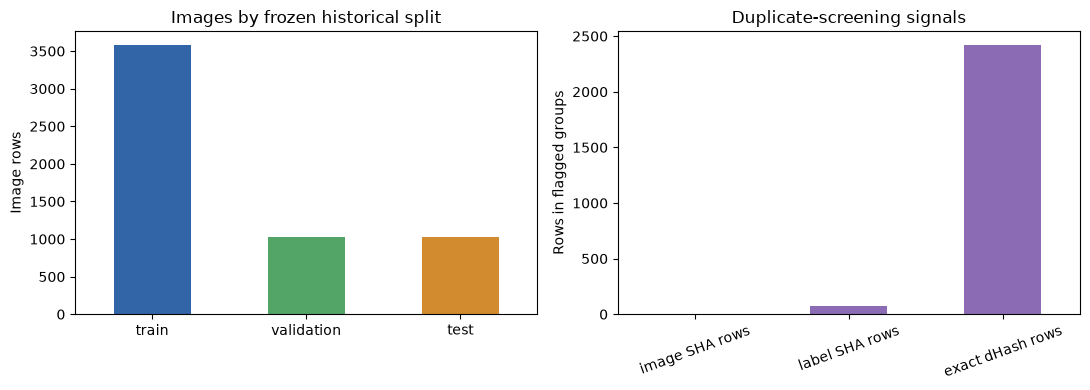

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
split_table["images"].plot(kind="bar", ax=axes[0], color=["#3264a8", "#53a567", "#d38b2f"])
axes[0].set_title("Images by frozen historical split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Image rows")
axes[0].tick_params(axis="x", rotation=0)

dup = report["duplicates"]
dup_plot = pd.Series({
    "image SHA rows": dup["duplicate_image_sha256_rows"],
    "label SHA rows": dup["duplicate_label_sha256_rows"],
    "exact dHash rows": dup["exact_dhash64_rows"],
})
dup_plot.plot(kind="bar", ax=axes[1], color="#8b6bb3")
axes[1].set_title("Duplicate-screening signals")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rows in flagged groups")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [5]:
integrity = report["integrity"]
integrity_table = pd.DataFrame(
    [{"measure": key, "count": value} for key, value in integrity.items() if isinstance(value, int)]
)
display(integrity_table)

limitations = pd.DataFrame({"documented limitation": report["limitations"]})
display(limitations)


,measure,count
0,missing_images,0
1,missing_labels,0
2,missing_properties,0
3,unreadable_images,0
4,image_hash_mismatches,0
5,label_hash_mismatches,0
6,label_json_parse_failures,0
7,invalid_bbox_rows,0


,documented limitation
0,"The 5,632-image corpus is a selected accessibl..."
1,"TS.z05, TS.z06, and TS.z07 remain unavailable ..."
2,Specimen names and archive metadata do not est...
3,dHash screens visual similarity but does not r...
4,Original label object semantics and visible co...
5,The historical test split has already been acc...


## Takeaways

The automated checks establish file custody, manifest integrity, and
specimen-grouped split isolation. They do not validate the physical meaning or
visible correctness of inherited boxes, establish manufacturing-build
independence, restore missing source archives, or make the accessed historical
test split external. Those are explicit downstream gates.

Sources reviewed in this notebook: `data_integrity_report.json`,
`image_manifest.csv`, and `group_manifest.csv` generated from the copied
`data/study_v1/manifest.csv`.
